In [1]:
# powerRotor
# In the Powerlift folder, there are subfolders named after 4 yaw angles i.e. 270,276,282,285. Each subfolder in turn contains multiple subfolders named after the timestep say 19022.002, etc. 
# Each such subfolders has a file named "powerRotor". Thus, there are multiple files named "powerRotor" in the Powerlift folder structure.Can you go through all the subfolders in Powerlift, read each "powerRotor" file, extract all the values corresponding to the two columns: Time(s) and rotor power (W) in all the files.  Then concatenate them and create a csv file with three columns: the yaw angle (from the name of the subfolder to which the powerRotor file belongs), the  Time(s) and the rotor power (W).

In [2]:
import os
import pandas as pd
from pathlib import Path

# Base directory
base_dir = Path(r"c:\Users\mandart\A_MANDAR_DOCUMENTS\HAM_Wind_Energy\ResultMLYaw\PowerLift")

# Yaw angle folders
yaw_folders = ['270', '276', '282', '285']

# List to store all dataframes
all_data = []

# Iterate through each yaw angle folder
for yaw in yaw_folders:
    yaw_path = base_dir / yaw
    if yaw_path.exists():
        # Iterate through each timestep subfolder
        for timestep_folder in yaw_path.iterdir():
            if timestep_folder.is_dir():
                power_file = timestep_folder / 'powerRotor'
                if power_file.exists():
                    # Read the powerRotor file (space-separated, skip header)
                    df = pd.read_csv(power_file, sep=r'\s+', 
                                     names=['Turbine', 'Time(s)', 'dt(s)', 'rotor power (W)'],
                                     skiprows=1)
                    # Add yaw angle column
                    df['yaw_angle'] = int(yaw)
                    # Keep only the columns we need
                    df = df[['yaw_angle', 'Time(s)', 'rotor power (W)']]
                    all_data.append(df)
                    print(f"Loaded: {power_file}")

# Concatenate all dataframes
combined_df = pd.concat(all_data, ignore_index=True)

# Sort by yaw angle and time
combined_df = combined_df.sort_values(['yaw_angle', 'Time(s)']).reset_index(drop=True)

print(f"\nTotal records: {len(combined_df)}")
print(combined_df.head(10))

Loaded: c:\Users\mandart\A_MANDAR_DOCUMENTS\HAM_Wind_Energy\ResultMLYaw\PowerLift\270\19022.802301\powerRotor
Loaded: c:\Users\mandart\A_MANDAR_DOCUMENTS\HAM_Wind_Energy\ResultMLYaw\PowerLift\270\20222.802301\powerRotor
Loaded: c:\Users\mandart\A_MANDAR_DOCUMENTS\HAM_Wind_Energy\ResultMLYaw\PowerLift\270\20222.852301\powerRotor
Loaded: c:\Users\mandart\A_MANDAR_DOCUMENTS\HAM_Wind_Energy\ResultMLYaw\PowerLift\270\20522.802301\powerRotor
Loaded: c:\Users\mandart\A_MANDAR_DOCUMENTS\HAM_Wind_Energy\ResultMLYaw\PowerLift\276\19022.802301\powerRotor
Loaded: c:\Users\mandart\A_MANDAR_DOCUMENTS\HAM_Wind_Energy\ResultMLYaw\PowerLift\276\20522.802301\powerRotor
Loaded: c:\Users\mandart\A_MANDAR_DOCUMENTS\HAM_Wind_Energy\ResultMLYaw\PowerLift\282\19022.802301\powerRotor
Loaded: c:\Users\mandart\A_MANDAR_DOCUMENTS\HAM_Wind_Energy\ResultMLYaw\PowerLift\282\20222.852301\powerRotor
Loaded: c:\Users\mandart\A_MANDAR_DOCUMENTS\HAM_Wind_Energy\ResultMLYaw\PowerLift\285\19611.852301\powerRotor
Loaded: c:

In [3]:
# Save to CSV file
output_file = base_dir / 'powerRotor_combined.csv'
combined_df.to_csv(output_file, index=False)
print(f"CSV file saved to: {output_file}")

CSV file saved to: c:\Users\mandart\A_MANDAR_DOCUMENTS\HAM_Wind_Energy\ResultMLYaw\PowerLift\powerRotor_combined.csv


In [4]:
# Load the CSV file
csv_path = r"c:\Users\mandart\A_MANDAR_DOCUMENTS\HAM_Wind_Energy\ResultMLYaw\PowerLift\powerRotor_combined.csv"
df = pd.read_csv(csv_path)

print(f"Shape: {df.shape}")
print(df.head())

Shape: (2829, 3)
   yaw_angle       Time(s)  rotor power (W)
0        270  19022.802301     3.593848e+06
1        270  19118.333632     1.507120e+06
2        270  19202.966095     1.271730e+06
3        270  19290.167171     1.162377e+06
4        270  19379.515534     1.358793e+06


In [5]:
df.shape

(2829, 3)

# Machine Learning Model for Rotor Power Prediction with Uncertainty Quantification

## Strategy:
1. **Normalize time** to relative time (0 to 1) within each yaw trajectory so we can predict dynamics without knowing absolute time
2. Train a **Gaussian Process Regression** model with uncertainty quantification
3. Save the model for later inference
4. Create an **agent class** that can be called to predict power dynamics for any new yaw angle

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel, Matern
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load data
csv_path = r"c:\Users\mandart\A_MANDAR_DOCUMENTS\HAM_Wind_Energy\ResultMLYaw\PowerLift\powerRotor_combined.csv"
df = pd.read_csv(csv_path)

# Convert power from W to MW
df['rotor_power_MW'] = df['rotor power (W)'] / 1e6

# Create normalized time (0 to 1) within each yaw angle group
# This allows prediction without knowing absolute time
def normalize_time_per_group(group):
    t_min = group['Time(s)'].min()
    t_max = group['Time(s)'].max()
    if t_max > t_min:
        group['normalized_time'] = (group['Time(s)'] - t_min) / (t_max - t_min)
    else:
        group['normalized_time'] = 0.0
    return group

df = df.groupby('yaw_angle', group_keys=False).apply(normalize_time_per_group)

print("Data with normalized time:")
print(df.head(20))
print(f"\nUnique yaw angles: {df['yaw_angle'].unique()}")
print(f"Shape: {df.shape}")

Data with normalized time:
    yaw_angle       Time(s)  rotor power (W)  rotor_power_MW  normalized_time
0         270  19022.802301     3.593848e+06        3.593848         0.000000
1         270  19118.333632     1.507120e+06        1.507120         0.062439
2         270  19202.966095     1.271730e+06        1.271730         0.117754
3         270  19290.167171     1.162377e+06        1.162377         0.174748
4         270  19379.515534     1.358793e+06        1.358793         0.233146
5         270  19467.511590     1.489887e+06        1.489887         0.290660
6         270  19553.925899     1.084942e+06        1.084942         0.347140
7         270  19640.377862     1.238586e+06        1.238586         0.403644
8         270  19727.673937     9.643879e+05        0.964388         0.460700
9         270  19816.729760     1.617096e+06        1.617096         0.518907
10        270  19904.559497     1.368471e+06        1.368471         0.576312
11        270  19991.870307     1.144

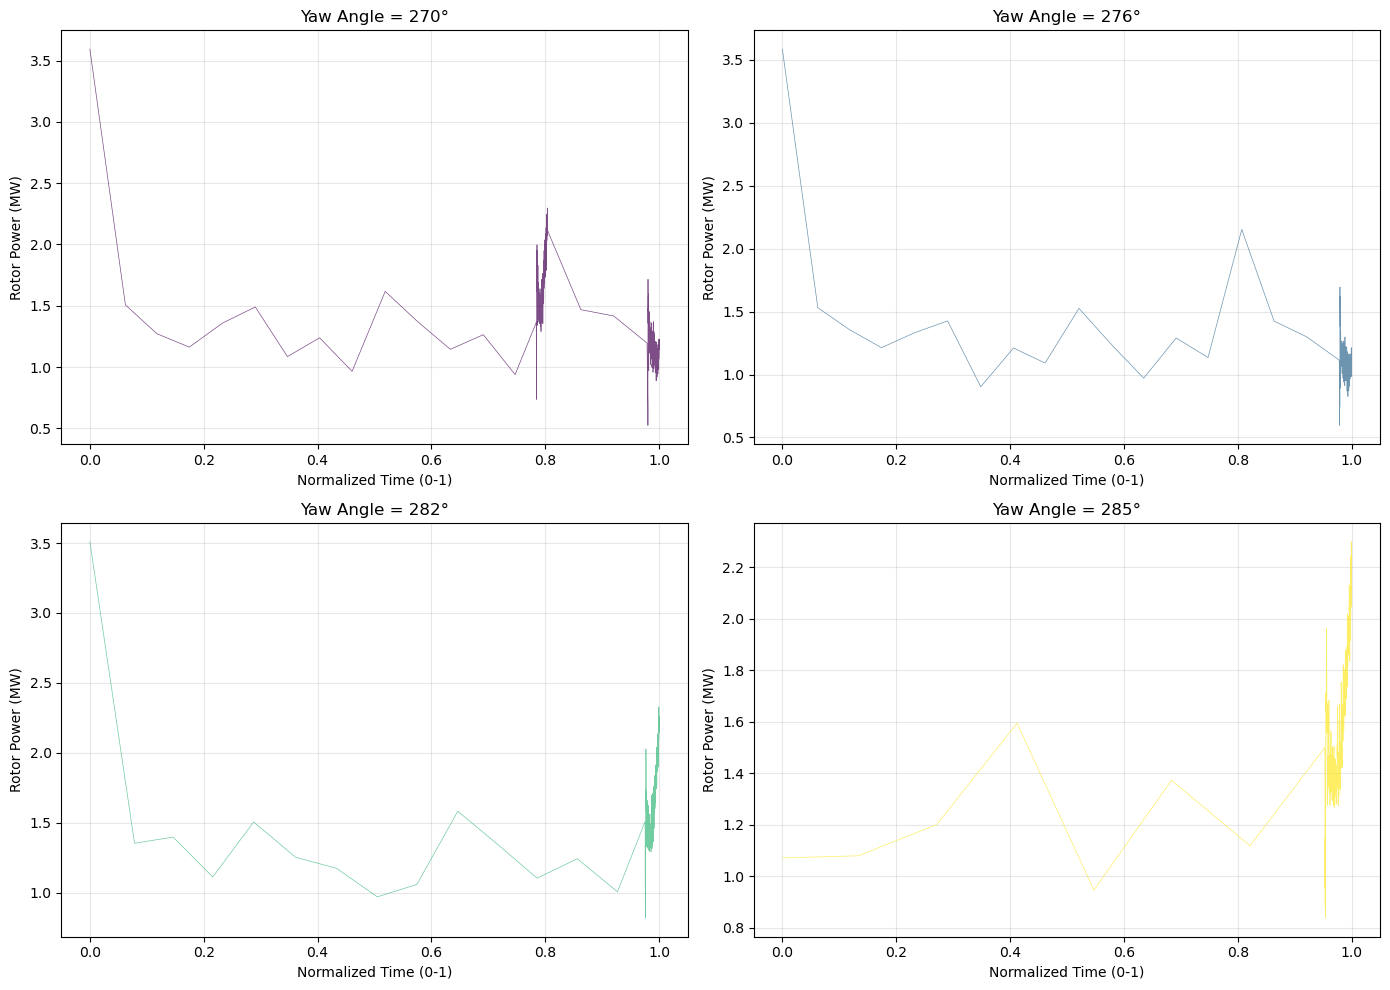

Power dynamics visualization saved to 'power_dynamics_by_yaw.png'


In [7]:
# Visualize the data - power dynamics for each yaw angle
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

yaw_angles = sorted(df['yaw_angle'].unique())
colors = plt.cm.viridis(np.linspace(0, 1, len(yaw_angles)))

for idx, yaw in enumerate(yaw_angles):
    yaw_data = df[df['yaw_angle'] == yaw]
    axes[idx].plot(yaw_data['normalized_time'], yaw_data['rotor_power_MW'], 
                   color=colors[idx], alpha=0.7, linewidth=0.5)
    axes[idx].set_xlabel('Normalized Time (0-1)')
    axes[idx].set_ylabel('Rotor Power (MW)')
    axes[idx].set_title(f'Yaw Angle = {yaw}°')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('power_dynamics_by_yaw.png', dpi=150)
plt.show()
print("Power dynamics visualization saved to 'power_dynamics_by_yaw.png'")

## Model Training with Uncertainty Quantification

We use **Gaussian Process Regression (GPR)** because:
1. It provides built-in **uncertainty quantification** (mean + variance)
2. It works well with small to medium datasets
3. It can capture non-linear relationships

For large datasets, we subsample to make GPR computationally feasible.

In [8]:
# Prepare features and target
# Features: yaw_angle, normalized_time
# Target: rotor_power_MW

X = df[['yaw_angle', 'normalized_time']].values
y = df['rotor_power_MW'].values

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# For GPR, we need to subsample if dataset is too large (GPR scales O(n^3))
# Use stratified sampling to maintain distribution across yaw angles
max_samples = 2000  # Adjust based on computational resources

if len(X) > max_samples:
    # Stratified sampling by yaw angle
    np.random.seed(42)
    sample_indices = []
    for yaw in df['yaw_angle'].unique():
        yaw_indices = df[df['yaw_angle'] == yaw].index.tolist()
        n_samples_yaw = int(max_samples * len(yaw_indices) / len(df))
        sampled = np.random.choice(yaw_indices, size=min(n_samples_yaw, len(yaw_indices)), replace=False)
        sample_indices.extend(sampled)
    
    X_train_full = X[sample_indices]
    y_train_full = y[sample_indices]
    print(f"Subsampled to {len(X_train_full)} samples for GPR training")
else:
    X_train_full = X
    y_train_full = y

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Features shape: (2829, 2)
Target shape: (2829,)
Subsampled to 1998 samples for GPR training
Training samples: 1598
Test samples: 400


In [9]:
# Normalize features for better GP performance
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

# Define GP kernel
# Matern kernel is good for physical processes (less smooth than RBF)
# Add WhiteKernel to model observation noise
kernel = (
    ConstantKernel(1.0, constant_value_bounds=(1e-3, 1e3)) * 
    Matern(length_scale=[1.0, 1.0], length_scale_bounds=(1e-3, 1e2), nu=2.5) +
    WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1))
)

# Train Gaussian Process Regressor
print("Training Gaussian Process model...")
print("This may take a few minutes depending on data size...")

gp_model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    alpha=1e-10,  # Numerical stability
    random_state=42
)

gp_model.fit(X_train_scaled, y_train_scaled)
print("Training complete!")
print(f"Optimized kernel: {gp_model.kernel_}")

Training Gaussian Process model...
This may take a few minutes depending on data size...
Training complete!
Optimized kernel: 0.908**2 * Matern(length_scale=[0.00603, 0.00317], nu=2.5) + WhiteKernel(noise_level=0.0143)


In [10]:
# Evaluate model on test set
y_pred_scaled, y_std_scaled = gp_model.predict(X_test_scaled, return_std=True)

# Transform predictions back to original scale
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
# For standard deviation, we need to scale by the y scaler's scale
y_std = y_std_scaled * scaler_y.scale_[0]

# Calculate metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation on Test Set:")
print(f"  RMSE: {rmse:.4f} MW")
print(f"  MAE: {mae:.4f} MW")
print(f"  R² Score: {r2:.4f}")

# Check uncertainty calibration
# ~68% of true values should fall within 1 std, ~95% within 2 std
within_1std = np.mean(np.abs(y_test - y_pred) <= y_std) * 100
within_2std = np.mean(np.abs(y_test - y_pred) <= 2*y_std) * 100
print(f"\nUncertainty Calibration:")
print(f"  % within 1 std (expect ~68%): {within_1std:.1f}%")
print(f"  % within 2 std (expect ~95%): {within_2std:.1f}%")

Model Evaluation on Test Set:
  RMSE: 0.1676 MW
  MAE: 0.0545 MW
  R² Score: 0.7815

Uncertainty Calibration:
  % within 1 std (expect ~68%): 72.5%
  % within 2 std (expect ~95%): 96.5%


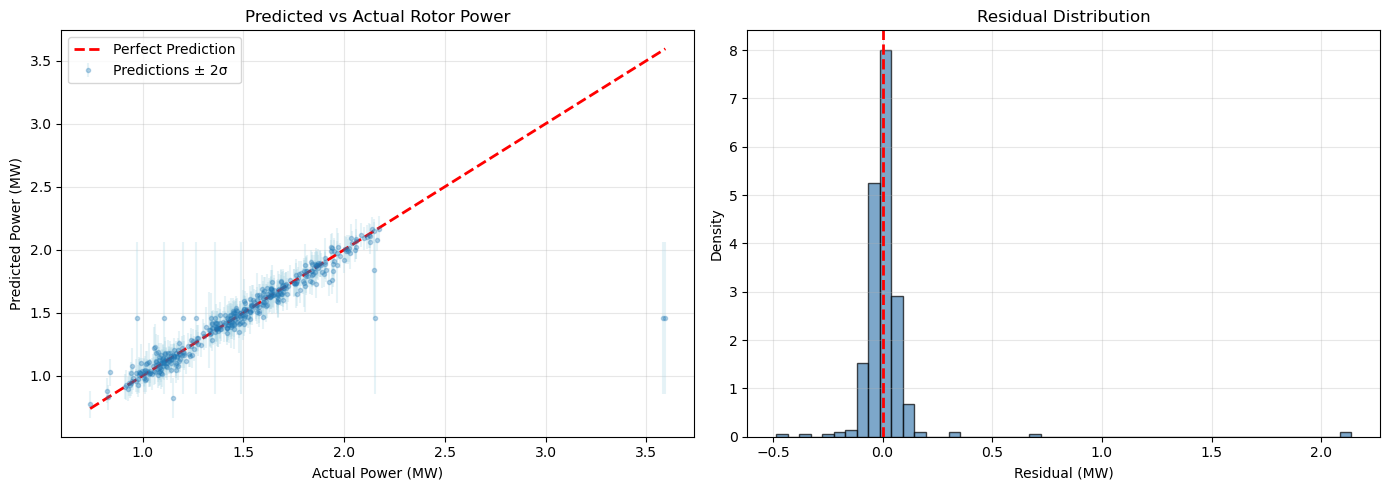

Model evaluation plot saved to 'model_evaluation.png'


In [11]:
# Visualization: Predicted vs Actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot with error bars
ax1 = axes[0]
ax1.errorbar(y_test, y_pred, yerr=2*y_std, fmt='o', alpha=0.3, markersize=3, 
             ecolor='lightblue', capsize=0, label='Predictions ± 2σ')
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
ax1.set_xlabel('Actual Power (MW)')
ax1.set_ylabel('Predicted Power (MW)')
ax1.set_title('Predicted vs Actual Rotor Power')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Residual distribution
ax2 = axes[1]
residuals = y_test - y_pred
ax2.hist(residuals, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Residual (MW)')
ax2.set_ylabel('Density')
ax2.set_title('Residual Distribution')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150)
plt.show()
print("Model evaluation plot saved to 'model_evaluation.png'")

## Save the Trained Model

We save the model and scalers so they can be loaded later for inference.

In [12]:
# Save model and scalers
model_path = r"c:\Users\mandart\A_MANDAR_DOCUMENTS\HAM_Wind_Energy\ResultMLYaw\PowerLift"

# Save all components needed for inference
model_artifacts = {
    'gp_model': gp_model,
    'scaler_X': scaler_X,
    'scaler_y': scaler_y,
    'yaw_angles_trained': sorted(df['yaw_angle'].unique().tolist()),
    'metadata': {
        'rmse_mw': rmse,
        'mae_mw': mae,
        'r2_score': r2,
        'n_training_samples': len(X_train),
        'features': ['yaw_angle', 'normalized_time'],
        'target': 'rotor_power_MW'
    }
}

joblib.dump(model_artifacts, f"{model_path}/rotor_power_gp_model.joblib")
print(f"Model saved to: {model_path}/rotor_power_gp_model.joblib")
print(f"\nModel artifacts saved:")
for key in model_artifacts:
    if key != 'metadata':
        print(f"  - {key}")
print(f"\nMetadata: {model_artifacts['metadata']}")

Model saved to: c:\Users\mandart\A_MANDAR_DOCUMENTS\HAM_Wind_Energy\ResultMLYaw\PowerLift/rotor_power_gp_model.joblib

Model artifacts saved:
  - gp_model
  - scaler_X
  - scaler_y
  - yaw_angles_trained

Metadata: {'rmse_mw': 0.16756034798741862, 'mae_mw': 0.054530793287361164, 'r2_score': 0.7814694330809663, 'n_training_samples': 1598, 'features': ['yaw_angle', 'normalized_time'], 'target': 'rotor_power_MW'}


## Rotor Power Prediction Agent

This class acts as an "agent" that you can call to infer rotor power dynamics for any yaw angle. It:
1. Loads the trained model
2. Predicts the full transient power trajectory for a given yaw angle
3. Returns mean predictions with uncertainty bounds
4. Provides visualization capabilities

In [13]:
class RotorPowerAgent:
    """
    Agent for predicting rotor power transient dynamics with uncertainty quantification.
    
    This agent loads a trained Gaussian Process model and provides methods to:
    - Predict power trajectories for any yaw angle
    - Quantify prediction uncertainty
    - Visualize transient dynamics
    
    Usage:
        agent = RotorPowerAgent(model_path)
        results = agent.predict(yaw_angle=278)
        agent.plot_prediction(results)
    """
    
    def __init__(self, model_path: str = None):
        """
        Initialize the agent by loading the trained model.
        
        Args:
            model_path: Path to the saved model file (.joblib)
        """
        if model_path is None:
            model_path = r"c:\Users\mandart\A_MANDAR_DOCUMENTS\HAM_Wind_Energy\ResultMLYaw\PowerLift\rotor_power_gp_model.joblib"
        
        print(f"Loading model from: {model_path}")
        artifacts = joblib.load(model_path)
        
        self.gp_model = artifacts['gp_model']
        self.scaler_X = artifacts['scaler_X']
        self.scaler_y = artifacts['scaler_y']
        self.yaw_angles_trained = artifacts['yaw_angles_trained']
        self.metadata = artifacts['metadata']
        
        print(f"Model loaded successfully!")
        print(f"Trained on yaw angles: {self.yaw_angles_trained}")
        print(f"Model performance: RMSE={self.metadata['rmse_mw']:.4f} MW, R²={self.metadata['r2_score']:.4f}")
    
    def predict(self, yaw_angle: float, n_time_points: int = 100, 
                return_samples: bool = False, n_samples: int = 100) -> dict:
        """
        Predict rotor power transient dynamics for a given yaw angle.
        
        Args:
            yaw_angle: The yaw angle (in degrees) for prediction
            n_time_points: Number of time points to predict (default: 100)
            return_samples: Whether to return posterior samples (default: False)
            n_samples: Number of posterior samples if return_samples=True
        
        Returns:
            dict with keys:
                - 'normalized_time': Array of normalized time points (0 to 1)
                - 'power_mean_MW': Predicted mean power (MW)
                - 'power_std_MW': Predicted standard deviation (MW)
                - 'power_lower_95': Lower 95% confidence bound (MW)
                - 'power_upper_95': Upper 95% confidence bound (MW)
                - 'yaw_angle': Input yaw angle
                - 'samples' (optional): Posterior samples if requested
        """
        # Check if yaw angle is within training range
        min_yaw = min(self.yaw_angles_trained)
        max_yaw = max(self.yaw_angles_trained)
        
        if yaw_angle < min_yaw or yaw_angle > max_yaw:
            print(f"⚠️ Warning: Yaw angle {yaw_angle}° is outside training range [{min_yaw}°, {max_yaw}°]")
            print("  Predictions may have higher uncertainty (extrapolation)")
        
        # Create prediction grid
        normalized_time = np.linspace(0, 1, n_time_points)
        X_pred = np.column_stack([
            np.full(n_time_points, yaw_angle),
            normalized_time
        ])
        
        # Scale features
        X_pred_scaled = self.scaler_X.transform(X_pred)
        
        # Predict with uncertainty
        y_pred_scaled, y_std_scaled = self.gp_model.predict(X_pred_scaled, return_std=True)
        
        # Transform back to original scale
        power_mean = self.scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
        power_std = y_std_scaled * self.scaler_y.scale_[0]
        
        # Compute confidence intervals (95% = ±1.96 std)
        power_lower_95 = power_mean - 1.96 * power_std
        power_upper_95 = power_mean + 1.96 * power_std
        
        results = {
            'normalized_time': normalized_time,
            'power_mean_MW': power_mean,
            'power_std_MW': power_std,
            'power_lower_95_MW': power_lower_95,
            'power_upper_95_MW': power_upper_95,
            'yaw_angle': yaw_angle
        }
        
        # Optional: return posterior samples for more detailed uncertainty analysis
        if return_samples:
            y_samples_scaled = self.gp_model.sample_y(X_pred_scaled, n_samples=n_samples, random_state=42)
            samples = self.scaler_y.inverse_transform(y_samples_scaled).T
            results['samples'] = samples
        
        return results
    
    def plot_prediction(self, results: dict, ax=None, show_samples: bool = False,
                        title: str = None, save_path: str = None):
        """
        Visualize the predicted power transient dynamics.
        
        Args:
            results: Output from predict() method
            ax: Matplotlib axis (creates new figure if None)
            show_samples: Whether to show posterior samples
            title: Custom plot title
            save_path: Path to save the figure
        """
        if ax is None:
            fig, ax = plt.subplots(figsize=(12, 6))
        
        t = results['normalized_time']
        yaw = results['yaw_angle']
        
        # Plot confidence interval
        ax.fill_between(t, results['power_lower_95_MW'], results['power_upper_95_MW'],
                        alpha=0.3, color='steelblue', label='95% Confidence Interval')
        
        # Plot ±1 std interval
        ax.fill_between(t, 
                        results['power_mean_MW'] - results['power_std_MW'],
                        results['power_mean_MW'] + results['power_std_MW'],
                        alpha=0.4, color='steelblue', label='±1σ Uncertainty')
        
        # Plot mean prediction
        ax.plot(t, results['power_mean_MW'], 'b-', linewidth=2, label='Mean Prediction')
        
        # Optionally plot samples
        if show_samples and 'samples' in results:
            for i, sample in enumerate(results['samples'][:20]):  # Plot first 20 samples
                ax.plot(t, sample, 'gray', alpha=0.2, linewidth=0.5)
        
        ax.set_xlabel('Normalized Time (0-1)', fontsize=12)
        ax.set_ylabel('Rotor Power (MW)', fontsize=12)
        
        if title is None:
            title = f'Predicted Rotor Power Transient Dynamics\nYaw Angle = {yaw}°'
        ax.set_title(title, fontsize=14)
        
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"Figure saved to: {save_path}")
        
        return ax
    
    def compare_yaw_angles(self, yaw_angles: list, n_time_points: int = 100,
                           save_path: str = None):
        """
        Compare power dynamics across multiple yaw angles.
        
        Args:
            yaw_angles: List of yaw angles to compare
            n_time_points: Number of time points for prediction
            save_path: Path to save the figure
        """
        fig, ax = plt.subplots(figsize=(14, 8))
        colors = plt.cm.viridis(np.linspace(0, 1, len(yaw_angles)))
        
        for i, yaw in enumerate(yaw_angles):
            results = self.predict(yaw_angle=yaw, n_time_points=n_time_points)
            
            # Plot mean with confidence interval
            ax.fill_between(results['normalized_time'], 
                           results['power_lower_95_MW'], 
                           results['power_upper_95_MW'],
                           alpha=0.2, color=colors[i])
            ax.plot(results['normalized_time'], results['power_mean_MW'], 
                   color=colors[i], linewidth=2, label=f'Yaw = {yaw}°')
        
        ax.set_xlabel('Normalized Time (0-1)', fontsize=12)
        ax.set_ylabel('Rotor Power (MW)', fontsize=12)
        ax.set_title('Comparison of Rotor Power Dynamics Across Yaw Angles', fontsize=14)
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"Figure saved to: {save_path}")
        
        plt.show()
        return fig
    
    def get_statistics(self, yaw_angle: float, n_time_points: int = 100) -> dict:
        """
        Get summary statistics for the predicted power dynamics.
        
        Args:
            yaw_angle: The yaw angle for prediction
            n_time_points: Number of time points
            
        Returns:
            dict with summary statistics
        """
        results = self.predict(yaw_angle, n_time_points)
        
        stats = {
            'yaw_angle': yaw_angle,
            'mean_power_MW': np.mean(results['power_mean_MW']),
            'max_power_MW': np.max(results['power_mean_MW']),
            'min_power_MW': np.min(results['power_mean_MW']),
            'power_range_MW': np.max(results['power_mean_MW']) - np.min(results['power_mean_MW']),
            'mean_uncertainty_MW': np.mean(results['power_std_MW']),
            'max_uncertainty_MW': np.max(results['power_std_MW'])
        }
        
        return stats

print("RotorPowerAgent class defined successfully!")

RotorPowerAgent class defined successfully!


## Test the Agent with New Yaw Angles

Now let's use the agent to infer rotor power dynamics for both trained and new (interpolated) yaw angles.

In [14]:
# Initialize the agent
agent = RotorPowerAgent()

# Predict for a new yaw angle (interpolation within training range)
new_yaw = 278  # Not in training set [270, 276, 282, 285]
print(f"\n{'='*60}")
print(f"Predicting transient dynamics for yaw angle = {new_yaw}°")
print(f"{'='*60}")

results = agent.predict(yaw_angle=new_yaw, n_time_points=100, return_samples=True, n_samples=50)

# Display results
print(f"\nPrediction Results:")
print(f"  Time points: {len(results['normalized_time'])}")
print(f"  Mean power range: {results['power_mean_MW'].min():.3f} - {results['power_mean_MW'].max():.3f} MW")
print(f"  Average uncertainty (±1σ): ±{results['power_std_MW'].mean():.3f} MW")

Loading model from: c:\Users\mandart\A_MANDAR_DOCUMENTS\HAM_Wind_Energy\ResultMLYaw\PowerLift\rotor_power_gp_model.joblib
Model loaded successfully!
Trained on yaw angles: [270, 276, 282, 285]
Model performance: RMSE=0.1676 MW, R²=0.7815

Predicting transient dynamics for yaw angle = 278°

Prediction Results:
  Time points: 100
  Mean power range: 1.457 - 1.457 MW
  Average uncertainty (±1σ): ±0.300 MW


Figure saved to: prediction_yaw_278.png


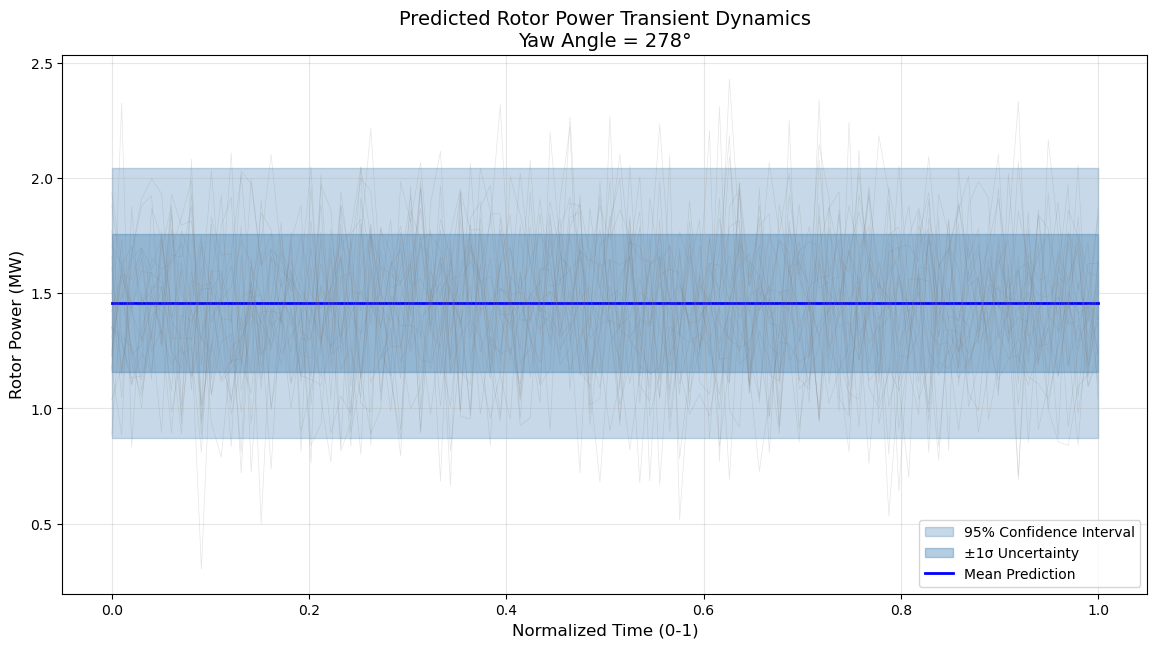

In [15]:
# Plot the prediction with uncertainty
fig, ax = plt.subplots(figsize=(14, 7))
agent.plot_prediction(results, ax=ax, show_samples=True, 
                      save_path='prediction_yaw_278.png')
plt.show()

Comparing yaw angles: [270, 275, 278, 280, 282, 285]
(Note: 275, 278, 280 are interpolated - not in original training data)
Figure saved to: yaw_comparison.png


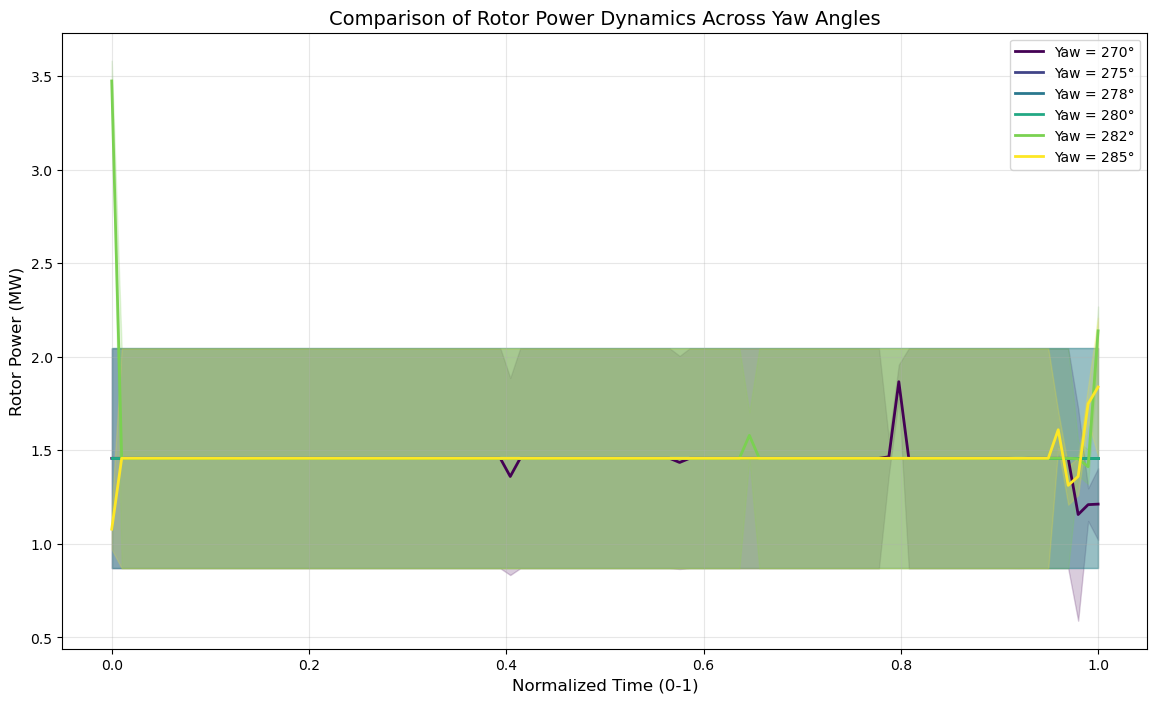

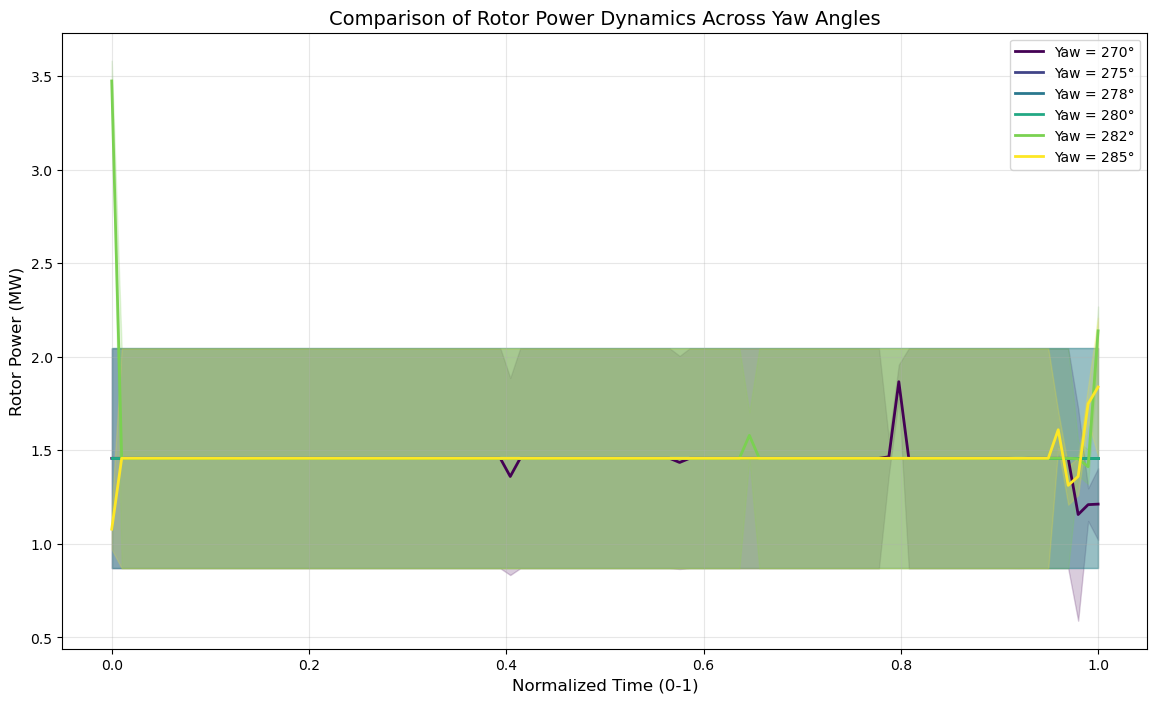

In [16]:
# Compare multiple yaw angles (trained + new)
yaw_angles_to_compare = [270, 275, 278, 280, 282, 285]
print("Comparing yaw angles:", yaw_angles_to_compare)
print("(Note: 275, 278, 280 are interpolated - not in original training data)")

agent.compare_yaw_angles(yaw_angles_to_compare, save_path='yaw_comparison.png')

In [17]:
# Get summary statistics for different yaw angles
print("\nSummary Statistics for Different Yaw Angles:")
print("-" * 80)
print(f"{'Yaw':>6} | {'Mean Power':>12} | {'Max Power':>12} | {'Min Power':>12} | {'Mean Uncert.':>12}")
print(f"{'(deg)':>6} | {'(MW)':>12} | {'(MW)':>12} | {'(MW)':>12} | {'(MW)':>12}")
print("-" * 80)

for yaw in [270, 273, 276, 279, 282, 285]:
    stats = agent.get_statistics(yaw)
    print(f"{stats['yaw_angle']:>6} | {stats['mean_power_MW']:>12.4f} | {stats['max_power_MW']:>12.4f} | "
          f"{stats['min_power_MW']:>12.4f} | {stats['mean_uncertainty_MW']:>12.4f}")


Summary Statistics for Different Yaw Angles:
--------------------------------------------------------------------------------
   Yaw |   Mean Power |    Max Power |    Min Power | Mean Uncert.
 (deg) |         (MW) |         (MW) |         (MW) |         (MW)
--------------------------------------------------------------------------------
   270 |       1.4525 |       1.8672 |       1.1570 |       0.2898
   273 |       1.4575 |       1.4575 |       1.4575 |       0.2999
   276 |       1.4502 |       1.5785 |       1.0174 |       0.2903
   279 |       1.4575 |       1.4575 |       1.4575 |       0.2999
   282 |       1.4852 |       3.4747 |       1.4125 |       0.2877
   285 |       1.4595 |       1.8388 |       1.0787 |       0.2864


## Standalone Agent Script

Save the agent as a standalone Python module that can be imported and used anywhere.

In [18]:
# Save the agent class as a standalone Python module
agent_script = '''"""
Rotor Power Prediction Agent with Uncertainty Quantification

This module provides an agent for predicting wind turbine rotor power 
transient dynamics based on yaw angle using a trained Gaussian Process model.

Usage:
    from rotor_power_agent import RotorPowerAgent
    
    # Initialize the agent (loads the trained model)
    agent = RotorPowerAgent()
    
    # Predict power dynamics for a new yaw angle
    results = agent.predict(yaw_angle=278)
    
    # Visualize the prediction
    agent.plot_prediction(results)
    
    # Compare multiple yaw angles
    agent.compare_yaw_angles([270, 275, 280, 285])
    
    # Get summary statistics
    stats = agent.get_statistics(yaw_angle=278)
"""

import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path


class RotorPowerAgent:
    """
    Agent for predicting rotor power transient dynamics with uncertainty quantification.
    
    This agent loads a trained Gaussian Process model and provides methods to:
    - Predict power trajectories for any yaw angle
    - Quantify prediction uncertainty
    - Visualize transient dynamics
    
    Attributes:
        gp_model: Trained Gaussian Process Regressor
        scaler_X: StandardScaler for input features
        scaler_y: StandardScaler for target variable
        yaw_angles_trained: List of yaw angles used in training
        metadata: Dictionary with model performance metrics
    """
    
    def __init__(self, model_path: str = None):
        """
        Initialize the agent by loading the trained model.
        
        Args:
            model_path: Path to the saved model file (.joblib).
                        If None, looks in the default location.
        """
        if model_path is None:
            # Default path - adjust as needed
            model_path = Path(__file__).parent / "rotor_power_gp_model.joblib"
        
        print(f"Loading model from: {model_path}")
        artifacts = joblib.load(model_path)
        
        self.gp_model = artifacts['gp_model']
        self.scaler_X = artifacts['scaler_X']
        self.scaler_y = artifacts['scaler_y']
        self.yaw_angles_trained = artifacts['yaw_angles_trained']
        self.metadata = artifacts['metadata']
        
        print(f"Model loaded successfully!")
        print(f"Trained on yaw angles: {self.yaw_angles_trained}")
        print(f"Model performance: RMSE={self.metadata['rmse_mw']:.4f} MW, R²={self.metadata['r2_score']:.4f}")
    
    def predict(self, yaw_angle: float, n_time_points: int = 100, 
                return_samples: bool = False, n_samples: int = 100) -> dict:
        """
        Predict rotor power transient dynamics for a given yaw angle.
        
        The model uses normalized time (0 to 1) to represent the transient
        trajectory, allowing predictions without knowing the absolute time.
        
        Args:
            yaw_angle: The yaw angle (in degrees) for prediction
            n_time_points: Number of time points to predict (default: 100)
            return_samples: Whether to return posterior samples (default: False)
            n_samples: Number of posterior samples if return_samples=True
        
        Returns:
            dict with keys:
                - 'normalized_time': Array of normalized time points (0 to 1)
                - 'power_mean_MW': Predicted mean power (MW)
                - 'power_std_MW': Predicted standard deviation (MW)
                - 'power_lower_95_MW': Lower 95% confidence bound (MW)
                - 'power_upper_95_MW': Upper 95% confidence bound (MW)
                - 'yaw_angle': Input yaw angle
                - 'samples' (optional): Posterior samples if requested
        """
        # Check if yaw angle is within training range
        min_yaw = min(self.yaw_angles_trained)
        max_yaw = max(self.yaw_angles_trained)
        
        if yaw_angle < min_yaw or yaw_angle > max_yaw:
            print(f"⚠️ Warning: Yaw angle {yaw_angle}° is outside training range [{min_yaw}°, {max_yaw}°]")
            print("  Predictions may have higher uncertainty (extrapolation)")
        
        # Create prediction grid
        normalized_time = np.linspace(0, 1, n_time_points)
        X_pred = np.column_stack([
            np.full(n_time_points, yaw_angle),
            normalized_time
        ])
        
        # Scale features
        X_pred_scaled = self.scaler_X.transform(X_pred)
        
        # Predict with uncertainty
        y_pred_scaled, y_std_scaled = self.gp_model.predict(X_pred_scaled, return_std=True)
        
        # Transform back to original scale
        power_mean = self.scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
        power_std = y_std_scaled * self.scaler_y.scale_[0]
        
        # Compute confidence intervals (95% = ±1.96 std)
        power_lower_95 = power_mean - 1.96 * power_std
        power_upper_95 = power_mean + 1.96 * power_std
        
        results = {
            'normalized_time': normalized_time,
            'power_mean_MW': power_mean,
            'power_std_MW': power_std,
            'power_lower_95_MW': power_lower_95,
            'power_upper_95_MW': power_upper_95,
            'yaw_angle': yaw_angle
        }
        
        # Optional: return posterior samples
        if return_samples:
            y_samples_scaled = self.gp_model.sample_y(X_pred_scaled, n_samples=n_samples, random_state=42)
            samples = self.scaler_y.inverse_transform(y_samples_scaled).T
            results['samples'] = samples
        
        return results
    
    def plot_prediction(self, results: dict, ax=None, show_samples: bool = False,
                        title: str = None, save_path: str = None):
        """
        Visualize the predicted power transient dynamics.
        
        Args:
            results: Output from predict() method
            ax: Matplotlib axis (creates new figure if None)
            show_samples: Whether to show posterior samples
            title: Custom plot title
            save_path: Path to save the figure
            
        Returns:
            matplotlib axis object
        """
        if ax is None:
            fig, ax = plt.subplots(figsize=(12, 6))
        
        t = results['normalized_time']
        yaw = results['yaw_angle']
        
        # Plot confidence interval
        ax.fill_between(t, results['power_lower_95_MW'], results['power_upper_95_MW'],
                        alpha=0.3, color='steelblue', label='95% Confidence Interval')
        
        # Plot ±1 std interval
        ax.fill_between(t, 
                        results['power_mean_MW'] - results['power_std_MW'],
                        results['power_mean_MW'] + results['power_std_MW'],
                        alpha=0.4, color='steelblue', label='±1σ Uncertainty')
        
        # Plot mean prediction
        ax.plot(t, results['power_mean_MW'], 'b-', linewidth=2, label='Mean Prediction')
        
        # Optionally plot samples
        if show_samples and 'samples' in results:
            for sample in results['samples'][:20]:
                ax.plot(t, sample, 'gray', alpha=0.2, linewidth=0.5)
        
        ax.set_xlabel('Normalized Time (0-1)', fontsize=12)
        ax.set_ylabel('Rotor Power (MW)', fontsize=12)
        
        if title is None:
            title = f'Predicted Rotor Power Transient Dynamics\\nYaw Angle = {yaw}°'
        ax.set_title(title, fontsize=14)
        
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"Figure saved to: {save_path}")
        
        return ax
    
    def compare_yaw_angles(self, yaw_angles: list, n_time_points: int = 100,
                           save_path: str = None):
        """
        Compare power dynamics across multiple yaw angles.
        
        Args:
            yaw_angles: List of yaw angles to compare
            n_time_points: Number of time points for prediction
            save_path: Path to save the figure
            
        Returns:
            matplotlib figure object
        """
        fig, ax = plt.subplots(figsize=(14, 8))
        colors = plt.cm.viridis(np.linspace(0, 1, len(yaw_angles)))
        
        for i, yaw in enumerate(yaw_angles):
            results = self.predict(yaw_angle=yaw, n_time_points=n_time_points)
            
            ax.fill_between(results['normalized_time'], 
                           results['power_lower_95_MW'], 
                           results['power_upper_95_MW'],
                           alpha=0.2, color=colors[i])
            ax.plot(results['normalized_time'], results['power_mean_MW'], 
                   color=colors[i], linewidth=2, label=f'Yaw = {yaw}°')
        
        ax.set_xlabel('Normalized Time (0-1)', fontsize=12)
        ax.set_ylabel('Rotor Power (MW)', fontsize=12)
        ax.set_title('Comparison of Rotor Power Dynamics Across Yaw Angles', fontsize=14)
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"Figure saved to: {save_path}")
        
        plt.show()
        return fig
    
    def get_statistics(self, yaw_angle: float, n_time_points: int = 100) -> dict:
        """
        Get summary statistics for the predicted power dynamics.
        
        Args:
            yaw_angle: The yaw angle for prediction
            n_time_points: Number of time points
            
        Returns:
            dict with summary statistics
        """
        results = self.predict(yaw_angle, n_time_points)
        
        return {
            'yaw_angle': yaw_angle,
            'mean_power_MW': np.mean(results['power_mean_MW']),
            'max_power_MW': np.max(results['power_mean_MW']),
            'min_power_MW': np.min(results['power_mean_MW']),
            'power_range_MW': np.max(results['power_mean_MW']) - np.min(results['power_mean_MW']),
            'mean_uncertainty_MW': np.mean(results['power_std_MW']),
            'max_uncertainty_MW': np.max(results['power_std_MW'])
        }


# Example usage when run as script
if __name__ == "__main__":
    # Initialize agent
    agent = RotorPowerAgent()
    
    # Predict for a new yaw angle
    results = agent.predict(yaw_angle=278, return_samples=True)
    
    # Plot prediction
    agent.plot_prediction(results, show_samples=True)
    plt.show()
    
    # Print statistics
    stats = agent.get_statistics(278)
    print("\\nStatistics for yaw=278°:")
    for key, value in stats.items():
        print(f"  {key}: {value:.4f}" if isinstance(value, float) else f"  {key}: {value}")
'''

# Save the agent module
agent_path = r"c:\Users\mandart\A_MANDAR_DOCUMENTS\HAM_Wind_Energy\ResultMLYaw\PowerLift\rotor_power_agent.py"
with open(agent_path, 'w') as f:
    f.write(agent_script)

print(f"Agent module saved to: {agent_path}")
print("\nYou can now import and use the agent from anywhere:")
print("  from rotor_power_agent import RotorPowerAgent")
print("  agent = RotorPowerAgent(model_path='path/to/model.joblib')")
print("  results = agent.predict(yaw_angle=278)")

Agent module saved to: c:\Users\mandart\A_MANDAR_DOCUMENTS\HAM_Wind_Energy\ResultMLYaw\PowerLift\rotor_power_agent.py

You can now import and use the agent from anywhere:
  from rotor_power_agent import RotorPowerAgent
  agent = RotorPowerAgent(model_path='path/to/model.joblib')
  results = agent.predict(yaw_angle=278)


## Quick Reference - How to Use the Agent

```python
# 1. Import the agent
from rotor_power_agent import RotorPowerAgent

# 2. Initialize (loads the trained model)
agent = RotorPowerAgent(model_path='rotor_power_gp_model.joblib')

# 3. Predict power dynamics for any yaw angle
results = agent.predict(yaw_angle=278, n_time_points=100)

# Access predictions:
# - results['normalized_time']  : Array of time points (0 to 1)
# - results['power_mean_MW']    : Mean predicted power (MW)
# - results['power_std_MW']     : Uncertainty (standard deviation)
# - results['power_lower_95_MW']: Lower 95% confidence bound
# - results['power_upper_95_MW']: Upper 95% confidence bound

# 4. Visualize
agent.plot_prediction(results, show_samples=True)

# 5. Compare multiple yaw angles
agent.compare_yaw_angles([270, 275, 280, 285])

# 6. Get summary statistics
stats = agent.get_statistics(yaw_angle=278)
```